## Identification Rate Metric

При обучении модели для распознавания лиц с помощью CE (кросс-энтропии) мы можем считать метрику accuracy как индикатор того, насколько хорошо наша модель работает. Но у accuracy тут есть недостаток: она не сможет померить, насколько хорошо наша модель работает на лицах людей, которых нет в обучающей выборке.  

Чтобы это исправить, придумали новую метрику: **identification rate**. Вот как она работает:

Создадим два набора изображений лиц: query и distractors. Никакие лица из этих наборов не должны содержаться в обучающем и валидационном датасете.

1. Посчитаем косинусные сходства между лицами, соответствующими одним и тем же людям из query части. Например, пусть одному человеку соответствуют три фото в query: 01.jpg, 02.jpg, 03.jpg. Тогда считаем три косинусных сходства между всеми тремя парами из этих фото.
2. Посчитаем косинусные сходства между лицами, соответствующими разным людям из query части.
3. Посчитаем косинусные сходства между всеми парами лиц из query и distractors. Т.е. пара — это (лицо из query, лицо из distractors). Всего получится |query|*|distractors| пар.
4. Сложим количества пар, полученных на 2 и 3 шагах. Это количество false пар.
5. Зафиксируем **FPR** (false positive rate). Пусть, например, будет 0.01. FPR, умноженный на количество false пар из шага 4 — это разрешенное количество false positives, которые мы разрешаем нашей модели. Обозначим это количество через N.
6. Отсортируем все значения косинусных сходств false пар в порядке убывания. N — ое значение расстояния зафиксируем как **пороговое расстояние**.
7. Посчитаем количество positive пар с шага 1, которые имеют косинусное сходство больше, чем пороговое расстояние. Поделим это количество на общее количество positive пар с шага 1. Это будет TPR (true positive rate) — итоговое значение нашей метрики.

Такая метрика обычно обозначается как TPR@FPR=0.01. FPR может быть разным. Приразных FPR будет получаться разное TPR.

Смысл этой метрики в том, что мы фиксируем вероятность ошибки вида false positive, т.е. когда "сеть сказала, что это один и тот же человек, но это не так", считаем порог косинусного сходства для этого значения ошибки, потом берем все positive пары и смотрим, у скольких из них сходство меньше этого порога. Т.е. насколько точно наша сеть ищет похожие лица при заданной вероятности ошибки вида false positive.

**Для подсчета метрик, то вам нужно разбить данные на query и distractors самим.**

Делается это примерно так:
- Выбраете несколько id, которые не использовались при тренировке моделей, и помещаете их в query set;
- Выбираете несколько id, которые не использовались при тренировке моделей и не входят в query, и помещаете их в distractors set. Обычно distractors set должен быть сильно больше, чем query set.
- Обрабатываете картинки из query и distractors тем же способом, что картинки для обучения сети.


Обратите внимание, что если картинок в query и distractors очень много, то полученных пар картинок в пунктах 1-2-3 алгоритма подсчета TPR@FPR будет очень-очень много. Чтобы код подсчета работал быстрее, ограничивайте размеры этих датасетов. Контролируйте, сколько значений расстояний вы считаете.

Ниже дан шаблон кода для реализации FPR@TPR метрики и ячейки с тестами. Тесты проверяют, что ваш код в ячейках написан правильно.

## План заданий

* Правильно разбить датасет на query и distractors
* Реализовать метрику и пройти все тесты
* Подгрузить все модели, обученные на разных лоссах и сравнить их метрики

## Шаблон кода для Identificaton rate metric (TPR@FPR)

In [1]:
from collections import defaultdict
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
def compute_embeddings(model, images_list, root_path):
    '''
    compute embeddings from the trained model for list of images.
    params:
    model: trained nn model that takes images and outputs embeddings
    images_list: list of images paths to compute embeddings for
    output:
    list: list of model embeddings. Each embedding corresponds to images
          names from images_list
    '''
    embeddings = []
    
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)
    
    transform = A.Compose([
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ])
    
    batch_size = 64
    
    dataset = ImageDataset(images_list, root_path, transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader):
            batch_embeddings = model(batch)
            embeddings.extend(list(batch_embeddings.numpy()))

    return embeddings


class ImageDataset(Dataset):
    def __init__(self, images_list, root_path, transform):
        self.images_list = images_list
        self.root_path = root_path
        self.transform = transform

    def __getitem__(self, item):
        path = f'{self.root_path}/{self.images_list[item]}'
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transform(image=image)['image']
        return image

    def __len__(self):
        return len(self.images_list)


In [3]:
def compute_cosine_query_pos(query_dict, query_img_names, query_embeddings):
    '''
    compute cosine similarities between positive pairs from query (stage 1)
    params:
    query_dict: dict {class: [image_name_1, image_name_2, ...]}. Key: class in
                the dataset. Value: images corresponding to that class
    query_img_names: list of images names
    query_embeddings: list of embeddings corresponding to query_img_names
    output:
    list of floats: similarities between embeddings corresponding
                    to the same people from query list
    '''
    similarities = []
    
    n2e = dict(zip(query_img_names, query_embeddings))
    for names in query_dict.values():
        for name1, name2 in combinations(names, 2):
            emb1 = [n2e[name1]]
            emb2 = [n2e[name2]]
            similarity = cosine_similarity(emb1, emb2)
            similarities.extend(similarity.flatten())
            
    return similarities


def compute_cosine_query_neg(query_dict, query_img_names, query_embeddings):
    '''
    compute cosine similarities between negative pairs from query (stage 2)
    params:
    query_dict: dict {class: [image_name_1, image_name_2, ...]}. Key: class in
                the dataset. Value: images corresponding to that class
    query_img_names: list of images names
    query_embeddings: list of embeddings corresponding to query_img_names
    output:
    list of floats: similarities between embeddings corresponding
                    to different people from query list
    '''
    similarities = []

    n2e = dict(zip(query_img_names, query_embeddings))
    for names1, names2 in combinations(query_dict.values(), 2):
        emb1 = [n2e[n] for n in names1]
        emb2 = [n2e[n] for n in names2]
        similarity = cosine_similarity(emb1, emb2)
        similarities.extend(similarity.flatten())

    return similarities


def compute_cosine_query_distractors(query_embeddings, distractors_embeddings):
    '''
    compute cosine similarities between negative pairs from query and distractors
    (stage 3)
    params:
    query_embeddings: list of embeddings corresponding to query_img_names
    distractors_embeddings: list of embeddings corresponding to distractors_img_names
    output:
    list of floats: similarities between pairs of people (q, d), where q is
                    embedding corresponding to photo from query, d —
                    embedding corresponding to photo from distractors
    '''
    similarity = cosine_similarity(query_embeddings, distractors_embeddings)
    return list(similarity.flatten())


Ячейка ниже проверяет, что код работает верно:

In [4]:
test_query_dict = {
    2876: ['1.jpg', '2.jpg', '3.jpg'],
    5674: ['5.jpg'],
    864:  ['9.jpg', '10.jpg'],
}
test_query_img_names = ['1.jpg', '2.jpg', '3.jpg', '5.jpg', '9.jpg', '10.jpg']
test_query_embeddings = [
                    [1.56, 6.45,  -7.68],
                    [-1.1 , 6.11,  -3.0],
                    [-0.06,-0.98,-1.29],
                    [8.56, 1.45,  1.11],
                    [0.7,  1.1,   -7.56],
                    [0.05, 0.9,   -2.56],
]

test_distractors_img_names = ['11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg']

test_distractors_embeddings = [
                    [0.12, -3.23, -5.55],
                    [-1,   -0.01, 1.22],
                    [0.06, -0.23, 1.34],
                    [-6.6, 1.45,  -1.45],
                    [0.89,  1.98, 1.45],
]

test_cosine_query_pos = compute_cosine_query_pos(test_query_dict, test_query_img_names,
                                            test_query_embeddings)
test_cosine_query_neg = compute_cosine_query_neg(test_query_dict, test_query_img_names,
                                            test_query_embeddings)
test_cosine_query_distractors = compute_cosine_query_distractors(test_query_embeddings,
                                                            test_distractors_embeddings)

In [5]:
true_cosine_query_pos = [0.8678237233650096, 0.21226104378511604,
                         -0.18355866977496182, 0.9787437979250561]
assert np.allclose(sorted(test_cosine_query_pos), sorted(true_cosine_query_pos)), \
      "A mistake in compute_cosine_query_pos function"

true_cosine_query_neg = [0.15963231223161822, 0.8507997093616965, 0.9272761484302097,
                         -0.0643994061127092, 0.5412660901220571, 0.701307100338029,
                         -0.2372575528216902, 0.6941032794522218, 0.549425446066643,
                         -0.011982733001947084, -0.0466679194884999]
assert np.allclose(sorted(test_cosine_query_neg), sorted(true_cosine_query_neg)), \
      "A mistake in compute_cosine_query_neg function"

true_cosine_query_distractors = [0.3371426578637511, -0.6866465610863652, -0.8456563512871669,
                                 0.14530087113136106, 0.11410510307646118, -0.07265097629002357,
                                 -0.24097699660707042,-0.5851992679925766, 0.4295494455718534,
                                 0.37604478596058194, 0.9909483738948858, -0.5881093317868022,
                                 -0.6829712976642919, 0.07546364489032083, -0.9130970963915521,
                                 -0.17463101988684684, -0.5229363015558941, 0.1399896725311533,
                                 -0.9258034013399499, 0.5295114163723346, 0.7811585442749943,
                                 -0.8208760031249596, -0.9905139680301821, 0.14969764653247228,
                                 -0.40749654525418444, 0.648660814944824, -0.7432584300096284,
                                 -0.9839696492435877, 0.2498741082804709, -0.2661183373780491]
assert np.allclose(sorted(test_cosine_query_distractors), sorted(true_cosine_query_distractors)), \
      "A mistake in compute_cosine_query_distractors function"

И, наконец, финальная функция, которая считает IR metric:

In [6]:
def compute_ir(cosine_query_pos, cosine_query_neg, cosine_query_distractors,
               fpr=0.1):
    '''
    compute identification rate using precomputer cosine similarities between pairs
    at given fpr
    params:
    cosine_query_pos: cosine similarities between positive pairs from query
    cosine_query_neg: cosine similarities between negative pairs from query
    cosine_query_distractors: cosine similarities between negative pairs
                              from query and distractors
    fpr: false positive rate at which to compute TPR
    output:
    float: threshold for given fpr
    float: TPR at given FPR
    '''
    positive_pairs_cosine = np.array(cosine_query_pos)
    false_pairs_cosine = np.concatenate((cosine_query_neg, cosine_query_distractors))

    N = int(len(false_pairs_cosine) * fpr)
    
    sorted_false_pairs_cosine = np.sort(false_pairs_cosine)[::-1]
    
    threshold = sorted_false_pairs_cosine[N]
    tpr = np.mean(positive_pairs_cosine > threshold)

    return threshold, tpr


И ячейки для ее проверки:

In [7]:
test_thr = []
test_tpr = []
for fpr in [0.5, 0.3, 0.1]:
  x, y = compute_ir(test_cosine_query_pos, test_cosine_query_neg,
                    test_cosine_query_distractors, fpr=fpr)
  test_thr.append(x)
  test_tpr.append(y)

In [8]:
true_thr = [-0.011982733001947084, 0.3371426578637511, 0.701307100338029]
assert np.allclose(np.array(test_thr), np.array(true_thr)), "A mistake in computing threshold"

true_tpr = [0.75, 0.5, 0.5]
assert np.allclose(np.array(test_tpr), np.array(true_tpr)), "A mistake in computing tpr"

А в ячейке ниже вы можете посчитать TPR@FPR для датасета с лицами. Давайте, например, посчитаем для значений fpr = [0.5, 0.2, 0.1, 0.05].

In [9]:
root_path = 'metric/'
query_root_path = 'metric/query/'
distractors_root_path = 'metric/distractors/'

In [10]:
query_df = pd.read_csv(f'{root_path}/query.csv', header=None)
distractors_df = pd.read_csv(f'{root_path}/distractors.csv', header=None)

In [11]:
query_img_names = list(query_df[0].values)
distractors_img_names = list(distractors_df[0].values)

In [12]:
def create_dict(df):
    result = defaultdict(list)
    for row in df.itertuples():
        result[row._2].append(row._1)
    return result

In [13]:
query_dict = create_dict(query_df)
distractors_dict = create_dict(distractors_df)

In [14]:
names = ['resnet18_ce', 'resnet18_arcface']
checkpoints = [
    'resnet18_ce.pth',
    'resnet18_arcface.pth',
]

In [15]:
models = []

for name, checkpoint in zip(names, checkpoints):
    model = torchvision.models.resnet18()
    model.fc = nn.Identity()
    model.load_state_dict(torch.load(f'checkpoints/{checkpoint}', weights_only=True, map_location='cpu'), strict=False)
    models.append(model)

In [16]:
query_embeddings = []
distractors_embeddings = []

for model in models:
    query_embeddings.append(compute_embeddings(model, query_img_names, query_root_path))
    distractors_embeddings.append(compute_embeddings(model, distractors_img_names, distractors_root_path))


100%|██████████| 16/16 [00:47<00:00,  2.97s/it]


In [17]:
cosine_query_pos = []
cosine_query_neg = []
cosine_query_distractors = []

for emb in query_embeddings:
    cosine_query_pos.append(compute_cosine_query_pos(query_dict, query_img_names, emb))
    cosine_query_neg.append(compute_cosine_query_neg(query_dict, query_img_names, emb))

for q_emb, d_emb in zip(query_embeddings, distractors_embeddings):
    cosine_query_distractors.append(compute_cosine_query_distractors(q_emb, d_emb))


In [18]:
fpr_list = [0.8, 0.5, 0.2, 0.1, 0.05, 0.01, 0.001, 0.0001, 0.00001]

In [19]:
thr_list = []
tpr_list = []

for name, pos, neg, dist in zip(names, cosine_query_pos, cosine_query_neg, cosine_query_distractors):
    thr = []
    tpr = []
    print(name)
    
    for fpr in fpr_list:
        x, y = compute_ir(pos, neg, dist, fpr=fpr)
        thr.append(x)
        tpr.append(y)
        print(f'FPR: {fpr}, Threshold: {x:.4f}, TPR: {y:.4f}')

    thr_list.append(thr)
    tpr_list.append(tpr)
    print('\n')


resnet18_ce
FPR: 0.8, Threshold: 0.4671, TPR: 0.9933
FPR: 0.5, Threshold: 0.5136, TPR: 0.9867
FPR: 0.2, Threshold: 0.5670, TPR: 0.9500
FPR: 0.1, Threshold: 0.5994, TPR: 0.8933
FPR: 0.05, Threshold: 0.6283, TPR: 0.8500
FPR: 0.01, Threshold: 0.6871, TPR: 0.6567
FPR: 0.001, Threshold: 0.7531, TPR: 0.3700
FPR: 0.0001, Threshold: 0.8037, TPR: 0.1833
FPR: 1e-05, Threshold: 0.8357, TPR: 0.0867


resnet18_arcface
FPR: 0.8, Threshold: 0.1870, TPR: 0.9933
FPR: 0.5, Threshold: 0.2287, TPR: 0.9600
FPR: 0.2, Threshold: 0.2803, TPR: 0.8200
FPR: 0.1, Threshold: 0.3163, TPR: 0.7233
FPR: 0.05, Threshold: 0.3585, TPR: 0.6000
FPR: 0.01, Threshold: 0.4594, TPR: 0.3033
FPR: 0.001, Threshold: 0.5397, TPR: 0.1367
FPR: 0.0001, Threshold: 0.8126, TPR: 0.0033
FPR: 1e-05, Threshold: 0.9526, TPR: 0.0000




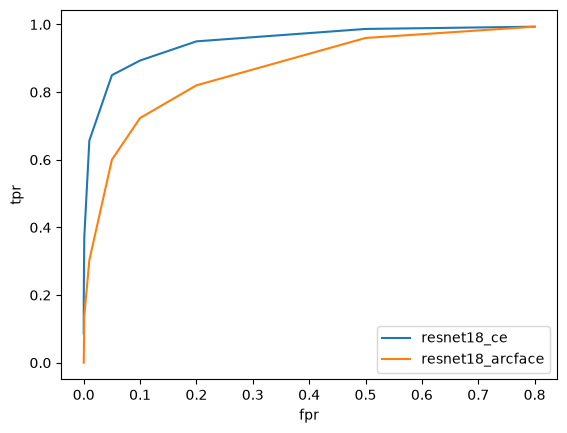

In [20]:
for name, tpr in zip(names, tpr_list):
    plt.plot(fpr_list, tpr, label=name)
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.legend()
plt.show()